# Topology optimization seeded by the $V_\mathrm{sca}$ dual bound

Global bound on the radiated power with GCD local constraints in the scattered-voltage basis (as in `VscatBound.ipynb`), a material density
fitted to the dual solution in the Lagrange matrix norm, and from this seed:

1. density-based topology optimization with GCMMA (`mmapy`) and $\beta$ continuation,
2. binary optimization by TSGA (topology sensitivity + genetic algorithm of AToM, ported to Python),

compared with the dual bound.

### Global bound in the scattered-voltage basis
Global bound on the radiated power with overall power conservation (real and imaginary part), formulated in the scattered voltage
$V_\mathrm{sca} = -Z_0 I$ instead of the current $I$ (alternative to `VtotBound.ipynb`, where $V_\mathrm{tot} = V + V_\mathrm{sca}$).

The pointwise relation $I_i^*\left(Z_s I_i - V_i - V_{\mathrm{sca},i}\right) = 0$ holds for any structure, so the left factor must stay $I$.
The current is eliminated through the field equation, valid everywhere,
$$I = -W V_\mathrm{sca}, \qquad W = Z_0^{-1} .$$
This is an invertible linear (not affine) change of variables, a pure shift of $V_\mathrm{tot}$ by the known $V$, so the bound must
coincide with the bound in the $I$ basis. Since $V_\mathrm{sca} = 0$ corresponds to the empty design region, the constant
term of every power conservation constraint vanishes, and all constraints (global and local) are of the shared projector form
of dolphindes, unlike in the $V_\mathrm{tot}$ basis, where they enter as general constraints.

In [1]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

np.random.seed(0)   # GCD and the checks draw random numbers: reproducible seed for the topology optimization

In [2]:
matrixSet = "patch21ka1"   # "dipole" | "patch21ka1": operators loaded from *_{matrixSet}.txt (both ka = 1)

# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [3]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(f"Lmat_{matrixSet}.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print(f"Matrix set: {matrixSet}, number of design variables: {Ndes}")

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(f"R0_{matrixSet}.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(f"X0_{matrixSet}.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(f"V_{matrixSet}.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ v)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix

def evalObjI(Ivec):
    # radiated power in the current basis
    return(0.5*np.real(Ivec.conj().T @ R0 @ Ivec))

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObjI(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Matrix set: patch21ka1, number of design variables: 233
Objective for full plate: 4.114174e-02 W


## Objective in $V_\mathrm{sca}$

With $I = -W V_\mathrm{sca}$ the radiated power $\tfrac12 I^H R_0 I$ takes the dolphindes form
$-x^H A_0 x + 2\operatorname{Re}(x^H s_0) + c_0$, $x = V_\mathrm{sca}$, with
$$A_0 = -\tfrac12 W^H R_0 W,\qquad s_0 = 0,\qquad c_0 = 0 .$$
The quadratic part is identical to the $V_\mathrm{tot}$ formulation.

In [4]:
print(f"cond(Z0) = {np.linalg.cond(Z0):.3e}")
W = np.linalg.inv(Z0)   # Z0^{-1}
WH = W.conj().T

Obj = -0.5 * Msym(WH @ R0 @ W)
obj = np.zeros(Ndes, dtype=complex)
obj0 = 0.0

def VtoI(Vsca):
    return(-W @ Vsca)

def evalObj(Vsca):
    return(-np.real(Vsca.conj().T @ Obj @ Vsca) + 2*np.real(Vsca.conj().T @ obj) + obj0)

Vfull = -Z0 @ Ifull # scattered voltage for full plate
print(f"Objective for full plate in Vsca: {evalObj(Vfull):.6e} W (I basis {Pfull:.6e} W)")

cond(Z0) = 1.174e+03
Objective for full plate in Vsca: 4.114174e-02 W (I basis 4.114174e-02 W)


## Power conservation in the shared projector form

For a complex diagonal projector $P = \operatorname{diag}(p)$ the constraint $\operatorname{Re}\left[I^H P (V + V_\mathrm{sca} - Z_s I)\right] = 0$
holds for any structure. With $I = -W V_\mathrm{sca}$ it reads $\operatorname{Re}\left(-x^H B x + 2x^H s\right) = 0$,
$$B = W^H P (1 + Z_s W),\qquad s = -\tfrac12 W^H P V ,$$
without a constant. Using $\operatorname{Re}(x^H B x) = \operatorname{Re}(x^H B^H x)$, $B^H = (1 + Z_s^* W^H)\, P^*\, W$, this is the shared projector form
$\operatorname{Re}\left(-x^H A_1 P' A_2 x + 2 x^H A_2^H P'^H s_1\right) = 0$ with
$$A_1 = 1 + Z_s^* W^H,\qquad A_2 = W,\qquad s_1 = -\tfrac12 V,\qquad P' = P^H = \operatorname{diag}(p^*),$$
i.e. the current-basis constraint with $U^H = A_1$ and $I = -A_2 x$ written in $V_\mathrm{sca}$.

The global real ($p = \mathbf 1$) and reactive ($p = -j\mathbf 1$) power constraints are $P' = \mathbf 1$ and $P' = j\mathbf 1$.
For $P' = \mathbf 1$, $\operatorname{Sym}(A_1 A_2) = W^H \operatorname{Re}(Z_\mathrm{tot}) W$ (using $\operatorname{Sym}W = W^H R_0 W$),
the congruent image of the $I$-basis real power constraint.

In [5]:
A1 = np.eye(Ndes) + np.conj(Zs) * WH
A2 = W
s1 = -0.5 * Vinc

qList = [1, -1j]   # real and imaginary part (real and reactive power), p = q 1
Plist = [sp.diags(np.conj(q)*np.ones(Ndes, dtype=complex)) for q in qList]   # P' = diag(p^*)

def projRes(x, Pp):
    # Re(-x^H A1 P' A2 x + 2 x^H A2^H P'^H s1)
    return(np.real(-x.conj() @ A1 @ (Pp @ (A2 @ x)) + 2*x.conj() @ (A2.conj().T @ (Pp.conj().T @ s1))))

def directRes(Vsca, p):
    # Re[I^H diag(p) (V + Vsca - Zs I)] evaluated directly
    I = VtoI(Vsca)
    return(np.real(np.sum(p*np.conj(I)*(Vinc + Vsca - Zs*I))))

print("power conservation residuals at full plate:",
      [f"{projRes(Vfull, Pp):.2e} (direct {directRes(Vfull, q*np.ones(Ndes)):.2e})" for Pp, q in zip(Plist, qList)])

# check: shared projector form equals the direct constraint for a random projector at a random point
pRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
print(f"random p, random x: shared form {projRes(xRand, sp.diags(np.conj(pRand))):.6e}, direct {directRes(xRand, pRand):.6e}")

power conservation residuals at full plate: ['-1.39e-17 (direct -2.89e-17)', '4.44e-16 (direct -4.76e-16)']
random p, random x: shared form -6.460829e+00, direct -6.460829e+00


## Dual problem

The unnormalized real power multiplier $\lambda > \tfrac12$ makes $A = -\tfrac12 W^H R_0 W + \lambda W^H \operatorname{Re}(Z_\mathrm{tot}) W$
positive definite, which gives a dual feasible starting point.

In [6]:
QCQP = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, Plist, A2=A2, verbose=1)

lags_init = np.array([1.0, 0.0])   # lambda = 1 on the real power constraint
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"bound: {result[0]:.6e} W, time: {time.time()-t1:.2f}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 2 A matrices and Fs vectors.
initial lags dual feasible: True
bound: 1.847944e+01 W, time: 0.14s, Lagrange multipliers: [ 8.83797881e-01 -4.10993941e-05]


In [7]:
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Vstar = QCQP.current_xstar
Istar = VtoI(Vstar)
print(f"dual bound {QCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W (I basis {evalObjI(Istar):.6e} W), full plate {Pfull:.6e} W")
print("constraint residuals at x*:", [f"{projRes(Vstar, Pp):.2e}" for Pp in Plist])

minimum eigenvalue of A: 6.851e-09
dual bound 1.847944e+01 W, P(x*) 1.847944e+01 W (I basis 1.847944e+01 W), full plate 4.114174e-02 W
constraint residuals at x*: ['-1.35e-07', '7.27e-04']


## Local projector constraints by GCD

Since the local constraints share $A_1$, $A_2$, $s_1$ with the global ones, they are generated directly by
`dolphindes.cvxopt.gcd.run_gcd`. Each GCD iteration adds two diagonal projectors $P' = \operatorname{diag}(p'^*)$:

1. **Strongest local violation:** $p'_i = (2s_1 - A_1^H x^\star)_i (A_2 x^\star)_i^*$, which equals
   $I_i^{\star *}\left(V + V^\star_{\mathrm{sca}} - Z_s I^\star\right)_i$ with $I^\star = -W x^\star$, the pointwise violation
   of the power conservation (zero for any physical structure).
2. **Minimal eigenvalue:** $p'_i = (A_1^H v)_i (A_2 v)_i^*$ for the eigenvector $v$ of $A(\lambda)$ with the smallest eigenvalue,
   normalized elementwise to unit modulus.

The projectors are kept orthonormal in the Hilbert-Schmidt metric of the constraints, and the number of projectors is capped at
`max_proj_cstrt_num`, which is set large enough that no constraints are merged within `max_gcd_iter_num` iterations.

In [8]:
import copy
from dolphindes.cvxopt.gcd import GCDHyperparameters

Ngcd = 100   # number of GCD iterations, each adds a max violation and a min eigenvalue projector

gQCQP = copy.deepcopy(QCQP)
gQCQP.verbose = 0
gcd_params = GCDHyperparameters(max_proj_cstrt_num=2 + 2*Ngcd,
    max_gcd_iter_num=Ngcd,
    gcd_iter_period=Ngcd + 1,   # no early termination
    opt_params=opt_params)

def localViolation(Vsca):
    # pointwise w_i = I_i^* (V + Vsca - Zs I)_i, zero for any physical structure
    I = VtoI(Vsca)
    return(np.conj(I)*(Vinc + Vsca - Zs*I))

t1 = time.time()
gQCQP.run_gcd(gcd_params)
print(f"bound: {QCQP.current_dual:.6e} -> {gQCQP.current_dual:.6e} W (full plate {Pfull:.6e} W), "
      f"{gQCQP.n_proj_constr} projectors, {time.time()-t1:.2f}s")

At GCD iteration #1, best dual bound found is             18.479439958269765.
min eigenvalue: 6.851365e-09


At GCD iteration #2, best dual bound found is             18.331563359435364.
min eigenvalue: 5.900530e-09


At GCD iteration #3, best dual bound found is             18.21958283974007.
min eigenvalue: 3.891569e-09


At GCD iteration #4, best dual bound found is             18.1163452970091.
min eigenvalue: 1.260089e-09


At GCD iteration #5, best dual bound found is             18.058141962621228.
min eigenvalue: 3.000895e-10


...

At GCD iteration #97, best dual bound found is             17.556795154864194.
min eigenvalue: 2.858323e-14


At GCD iteration #98, best dual bound found is             17.556269036007677.
min eigenvalue: 3.487283e-14


At GCD iteration #99, best dual bound found is             17.555002847347534.
min eigenvalue: 6.073231e-15


At GCD iteration #100, best dual bound found is             17.5527169693853.
min eigenvalue: 6.325007e-15


At GCD iteration #101, best dual bound found is             17.54994092018318.
bound: 1.847944e+01 -> 1.754994e+01 W (full plate 4.114174e-02 W), 202 projectors, 779.15s


minimum eigenvalue of A: 4.636e-15
dual bound 1.754994e+01 W, P(x*) 1.755013e+01 W
max |constraint residual| at x*: 6.43e+03 (global), 6.16e+03 (all)
||local violation||: global 5.419e+03, GCD 1.491e+03


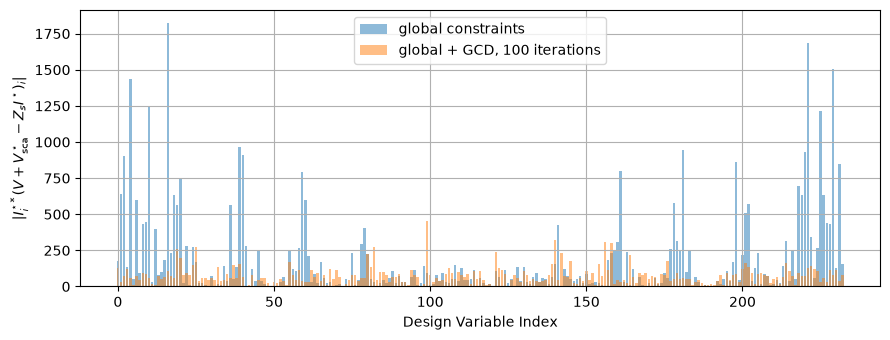

In [9]:
import matplotlib.pyplot as plt

Vstar = gQCQP.current_xstar
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(gQCQP._get_total_A(gQCQP.current_lags)))):.3e}")
print(f"dual bound {gQCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W")
PlistG = gQCQP.Proj.get_Pdata_column_stack()
print(f"max |constraint residual| at x*: {max(abs(projRes(Vstar, Pp)) for Pp in Plist):.2e} (global), "
      f"{max(abs(projRes(Vstar, sp.diags(PlistG[:, j]))) for j in range(PlistG.shape[1])):.2e} (all)")
print(f"||local violation||: global {np.linalg.norm(localViolation(QCQP.current_xstar)):.3e}, "
      f"GCD {np.linalg.norm(localViolation(Vstar)):.3e}")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(np.arange(Ndes), np.abs(localViolation(QCQP.current_xstar)), alpha=0.5, label='global constraints')
ax.bar(np.arange(Ndes), np.abs(localViolation(Vstar)), alpha=0.5, label=f'global + GCD, {Ngcd} iterations')
ax.set_xlabel('Design Variable Index'); ax.set_ylabel(r'$|I^{\star *}_i(V + V^\star_\mathrm{sca} - Z_s I^\star)_i|$')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## Seed: material density fitted in the Lagrange matrix norm

The dual solution $x^\star = V^\star_\mathrm{sca}$ is generally not realizable. The seed is the density $\rho\in[0,1]^N$ whose realized scattered voltage
is closest to $x^\star$ in the norm of the Lagrange matrix $L^\star = \operatorname{Sym}A(\lambda^\star) = C^H C$ at the optimal multipliers,
$$\min_{\rho\in[0,1]^N} \left\| C\left(x(\rho) - x^\star\right)\right\|^2,\qquad x(\rho) = -Z_0 I(\rho),\quad I(\rho) = (Z_s + \rho Z_0)^{-1}\rho V,$$
$$\frac{\partial x}{\partial \rho_j} = -Z_0 M^{-1} e_j \left(V - Z_0 I(\rho)\right)_j,\qquad M = Z_s + \rho Z_0 ,$$
i.e. the increase $J = (x - x^\star)^H L^\star (x - x^\star)$ of the Lagrangian over the dual value ($C = \Lambda^{1/2}U^H$ from the eigendecomposition,
as $L^\star$ is nearly singular). The fit is nonconvex (bounded trust region, `scipy.optimize.least_squares`), and its local solutions differ much as
seeds, so it is started from four initial guesses: the separable current fit $\rho_i = \operatorname{clip}(\operatorname{Re}(b_i^* I^\star_i)/|b_i|^2, 0, 1)$,
$b = (V + x^\star)/Z_s$, the Euclidean solution fit $\min\|I(\rho) - I^\star\|$ started from it, and the uniform densities $\tfrac12$ and $10^{-2}$.

In [10]:
from scipy.optimize import least_squares

def realizedObj(rho):
    # radiated power of the structure with density rho: (Zs + diag(rho) Z0) I = diag(rho) V
    S = rho.astype(complex)
    return evalObjI(np.linalg.solve(Zs*np.eye(Ndes) + S[:, None]*Z0, S*Vinc))

def realizedVsca(rho):
    S = rho.astype(complex)
    return -Z0 @ np.linalg.solve(Zs*np.eye(Ndes) + S[:, None]*Z0, S*Vinc)

def lagFactor(Q):
    # C with C^H C = Sym A(lambda*), from the eigendecomposition (L* is nearly singular)
    lam, U = np.linalg.eigh(Msym(Q._get_total_A(Q.current_lags)))
    return np.sqrt(np.maximum(lam, 0))[:, None] * U.conj().T

def stackRI(M):
    return np.vstack([M.real, M.imag]) if M.ndim == 2 else np.concatenate([M.real, M.imag])

def fitSolutionLag(Vsca, C, rho0):
    # argmin_{rho in [0,1]^N} || C (x(rho) - x*) ||, x(rho) = -Z0 (Zs + diag(rho) Z0)^{-1} diag(rho) V
    def model(rho):
        M = Zs*np.eye(Ndes) + rho[:, None]*Z0
        return M, np.linalg.solve(M, rho*Vinc)
    def fun(rho):
        return stackRI(C @ (-Z0 @ model(rho)[1] - Vsca))
    def jac(rho):
        M, Irho = model(rho)
        return stackRI(-(C @ Z0 @ np.linalg.inv(M)) * (Vinc - Z0 @ Irho)[None, :])
    sol = least_squares(fun, np.clip(rho0, 1e-3, 1 - 1e-3), jac=jac, bounds=(0, 1), method='trf',
                        xtol=1e-12, ftol=1e-12, max_nfev=500)
    res = np.linalg.norm(C @ (realizedVsca(sol.x) - Vsca))/np.linalg.norm(C @ Vsca)
    return sol.x, res

def fitDensityCurrent(Vsca):
    # initial guess: separable current fit argmin_{rho in [0,1]^N} || rho (V + Vsca)/Zs - I ||, I = -W Vsca
    b = (Vinc + Vsca)/Zs
    return np.clip(np.real(np.conj(b)*VtoI(Vsca))/np.abs(b)**2, 0, 1)

def fitSolutionEuclid(Vsca, rho0):
    # initial guess: argmin_{rho in [0,1]^N} || I(rho) - I* || in the Euclidean norm, I* = -W Vsca
    Istar = VtoI(Vsca)
    def model(rho):
        M = Zs*np.eye(Ndes) + rho[:, None]*Z0
        return M, np.linalg.solve(M, rho*Vinc)
    def jac(rho):
        M, Irho = model(rho)
        return stackRI(np.linalg.inv(M) * (Vinc - Z0 @ Irho)[None, :])
    return least_squares(lambda rho: stackRI(model(rho)[1] - Istar), np.clip(rho0, 1e-3, 1 - 1e-3), jac=jac,
                         bounds=(0, 1), method='trf', xtol=1e-12, ftol=1e-12, max_nfev=500).x

ths = np.linspace(0.05, 0.95, 19)   # thresholds for binarization

Vs, C = gQCQP.current_xstar, lagFactor(gQCQP)
r0 = fitDensityCurrent(Vs)
fitInits = {"current fit": r0, "Euclidean solution fit": fitSolutionEuclid(Vs, r0),
            "uniform 0.5": np.full(Ndes, 0.5), "uniform 0.01": np.full(Ndes, 0.01)}
fitSeeds = {}
for name, ri in fitInits.items():
    t1 = time.time()
    rho, res = fitSolutionLag(Vs, C, ri)
    fitSeeds[name] = rho
    P = realizedObj(rho)
    print(f"init {name:22s}: relative residual {res:.3e}, J {np.linalg.norm(C @ (realizedVsca(rho) - Vs))**2:.3e} W "
          f"(dual - P {gQCQP.current_dual - P:.3e} W), realized {P:.6e} W, mean density {rho.mean():.3e}, {time.time()-t1:.2f}s")

init current fit           : relative residual 9.659e-01, J 1.637e+01 W (dual - P 1.748e+01 W), realized 6.784892e-02 W, mean density 1.540e-04, 4.52s


init Euclidean solution fit: relative residual 8.720e-01, J 1.334e+01 W (dual - P 1.701e+01 W), realized 5.354631e-01 W, mean density 2.544e-02, 5.62s


init uniform 0.5           : relative residual 7.459e-01, J 9.764e+00 W (dual - P 1.238e+01 W), realized 5.171966e+00 W, mean density 1.591e-02, 5.53s


init uniform 0.01          : relative residual 7.387e-01, J 9.576e+00 W (dual - P 1.196e+01 W), realized 5.592418e+00 W, mean density 2.099e-02, 5.21s


## Density-based topology optimization (GCMMA)

The design is optimized for the radiated power of the realized structure with GCMMA (`mmapy`), following the density-based topology optimization in
the method of moments of J. Tucek, M. Capek, L. Jelinek, O. Sigmund, *IEEE TAP* 71, 9738 (2023), [arXiv:2303.15290](https://arxiv.org/abs/2303.15290),
and J. Tucek, M. Capek, L. Jelinek, [arXiv:2502.03985](https://doi.org/10.48550/arXiv.2502.03985) (2025).
Everything stays in the Cholesky basis (the density acts on the Cholesky basis functions, whose material matrix is the identity).

**Material interpolation.** $(Z_0 + \operatorname{diag} z(\bar\rho))\, I = V$ with the exponential surface impedance interpolation with a RAMP-like penalization,
$$z(\bar\rho) = Z_s \left(\frac{R_\mathrm{vac}}{\operatorname{Re} Z_s}\right)^{1 - f(\bar\rho)}, \qquad f(\bar\rho) = \frac{\bar\rho}{1 + p(1 - \bar\rho)},\qquad R_\mathrm{vac} = 10^7\,\Omega,\quad p = 1,$$
copper at $\bar\rho = 1$ and a vacuum-like sheet at $\bar\rho = 0$. The papers use $R_\mathrm{vac} = 10^5\,\Omega$ and note that it has to be checked for each
metric: for the radiated power of the resonant designs here, $10^5\,\Omega$ underestimated the exact power of thresholded designs by up to a factor of about 3
(in test runs), while for $10^7\,\Omega$ the model and the exact power agree within about 1%; $10^3$ to $10^6\,\Omega$ gave worse designs.
The fit model $(Z_s + \rho Z_0) I = \rho V$ is the reciprocal interpolation $z = Z_s/\rho$ (a density of $10^{-2}$ is still a good conductor), so the seed
is mapped by matching the impedance, $z(\bar\rho) = Z_s/\rho_\mathrm{seed}$, i.e. $f = 1 + \ln\rho_\mathrm{seed}/\ln(R_\mathrm{vac}/\operatorname{Re}Z_s)$ (clipped to $[0,1]$).

**Sensitivity.** With $M = Z_0 + \operatorname{diag} z$ and the adjoint $M^H\mu = R_0 I$,
$$\frac{\partial P}{\partial\bar\rho_j} = -\operatorname{Re}\left[\mu_j^*\, z'(\bar\rho_j)\, I_j\right],\qquad z' = -\ln\!\frac{R_\mathrm{vac}}{\operatorname{Re}Z_s}\, f'\, z .$$

**Projection and $\beta$ continuation** (Wang, Lazarov, Sigmund 2011) $\bar\rho = \dfrac{\tanh(\beta\eta) + \tanh(\beta(x - \eta))}{\tanh(\beta\eta) + \tanh(\beta(1 - \eta))}$, $\eta = \tfrac12$,
$\beta = 1, 2, 4, \dots, 32$, doubled every 75 iterations (arXiv:2502.03985) or earlier once $\max|x_i - x_{i-1}| \le 0.01$ after at least 75 iterations
(the plain $\Delta x$ criterion of the 2023 paper triggers almost immediately with the conservative GCMMA steps), move limit 0.25, stop when
$\max|x_i - x_{i-1}| \le 0.01$ at $\beta_\mathrm{max}$. The asymptotes are reset at each $\beta$. No density filter (no geometry in the Cholesky basis).

**Objective.** GCMMA minimizes $-\ln(P/P_\mathrm{full})$ with an inactive dummy constraint. The logarithm makes the objective scale invariant over the orders
of magnitude that $P$ spans between the seeds and resonant designs; in test runs it roughly doubled the power of the final designs compared to $-P/P_\mathrm{full}$
(plain MMA with the move limit 0.25 diverged, with 0.05 to 0.1 it gave worse designs than GCMMA).

The final design is the hard threshold $\bar\rho > \tfrac12$, evaluated with the exact physics (`realizedObj`, empty basis functions removed); the best
thresholded iterate is kept. The optimization is run from all four fitted seeds (multistart) and, as the reference, from the uniform $\bar\rho = \tfrac12$.

In [11]:
from mmapy import gcmmasub, asymp, concheck, raaupdate, kktcheck
from scipy.linalg import lu_factor, lu_solve

Rvac, pRamp = 1e7, 1.0                 # vacuum resistivity and RAMP penalty of the interpolation
lnK = np.log(Rvac/np.real(Zs))          # z(rho) = Zs K^(1 - f(rho)), K = Rvac/Re Zs

def interpZ(rho):
    # exponential (RAMP-like) surface impedance interpolation and its derivative
    f = rho/(1 + pRamp*(1 - rho))
    df = (1 + pRamp)/(1 + pRamp*(1 - rho))**2
    z = Zs*np.exp(lnK*(1 - f))
    return z, -lnK*df*z

def seedToExp(rho):
    # density of the exponential interpolation with the same impedance as Zs/rho (reciprocal model of the seed)
    f = np.clip(1 + np.log(np.maximum(rho, 1e-300))/lnK, 0, 1)
    return (1 + pRamp)*f/(1 + pRamp*f)

def physObjExp(rho):
    # P and dP/drho for (Z0 + diag z(rho)) I = V
    z, dz = interpZ(rho)
    lu = lu_factor(Z0 + np.diag(z))
    I = lu_solve(lu, Vinc)
    RI = R0 @ I
    mu = lu_solve(lu, RI, trans=2)
    return 0.5*np.real(np.vdot(I, RI)), -np.real(np.conj(mu)*dz*I)

def project(x, beta, eta=0.5):
    den = np.tanh(beta*eta) + np.tanh(beta*(1 - eta))
    return (np.tanh(beta*eta) + np.tanh(beta*(x - eta)))/den, beta*(1 - np.tanh(beta*(x - eta))**2)/den

def unproject(rho, beta, eta=0.5):
    den = np.tanh(beta*eta) + np.tanh(beta*(1 - eta))
    t = np.clip(rho*den - np.tanh(beta*eta), -1 + 1e-15, 1 - 1e-15)
    return np.clip(eta + np.arctanh(t)/beta, 0, 1)

def gcmmaTopOpt(rho0, physObj, beta0=1, betamax=32, maxit=600, dxtol=0.01, betaEvery=75, minPerBeta=75, move=0.25,
                Pref=1.0, logObj=True, verbose=True):
    # GCMMA with the beta continuation of Tucek et al.: beta doubles every betaEvery iterations, or earlier when
    # max|x_i - x_{i-1}| <= dxtol after minPerBeta iterations, up to betamax; stop when converged at betamax or after maxit
    # iterations; minimizes -log(P/Pref) (logObj) or -P/Pref
    n, m = Ndes, 1
    a0, a, c, d = 1.0, np.zeros((m, 1)), 1000*np.ones((m, 1)), np.ones((m, 1))
    epsimin, raa0eps, raaeps, maxinnerit = 1e-7, 1e-6, 1e-6*np.ones((m, 1)), 15
    beta = beta0
    xval = unproject(np.clip(rho0, 0, 1), beta)[:, None]
    hist, best = [], (-np.inf, None)

    def fun(x):
        rho, drho = project(x.ravel(), beta)
        P, dP = physObj(rho)
        if logObj:   # f0 = -log(P/Pref)
            return -np.log(P/Pref), -(dP*drho/P)[:, None], np.array([[-1.0]]), np.zeros((1, n)), P
        return -P/Pref, -(dP*drho/Pref)[:, None], np.array([[-1.0]]), np.zeros((1, n)), P   # dummy constraint

    def restart():
        return xval.copy(), xval.copy(), np.zeros((n, 1)), np.ones((n, 1)), 0
    xold1, xold2, low, upp, k = restart()
    f0val, df0dx, fval, dfdx, P = fun(xval)
    raa0, raa = 0.01, 0.01*np.ones((m, 1))
    for it in range(1, maxit + 1):
        k += 1
        xmin, xmax = np.maximum(0, xval - move), np.minimum(1, xval + move)   # move limit
        low, upp, raa0, raa = asymp(k, n, xval, xold1, xold2, xmin, xmax, low, upp, raa0, raa, raa0eps, raaeps, df0dx, dfdx)
        args = (m, n, k, epsimin, xval, xmin, xmax, low, upp)
        sub = gcmmasub(*args, raa0, raa, f0val, df0dx, fval, dfdx, a0, a, c, d)
        f0new, _, fnew, _, _ = fun(sub[0])
        innerit = 0
        while concheck(m, epsimin, sub[9], f0new, sub[10], fnew) == 0 and innerit < maxinnerit:
            innerit += 1
            raa0, raa = raaupdate(sub[0], xval, xmin, xmax, low, upp, f0new, fnew, sub[9], sub[10], raa0, raa, raa0eps, raaeps, epsimin)
            sub = gcmmasub(*args, raa0, raa, f0val, df0dx, fval, dfdx, a0, a, c, d)
            f0new, _, fnew, _, _ = fun(sub[0])
        dx = np.max(np.abs(sub[0] - xval))
        xold2, xold1, xval = xold1.copy(), xval.copy(), sub[0].copy()
        f0val, df0dx, fval, dfdx, P = fun(xval)
        rho = project(xval.ravel(), beta)[0]
        rhoB = (rho > 0.5).astype(float)
        Pbin = physObj(rhoB)[0]
        if Pbin > best[0]:
            best = (Pbin, rhoB)
        hist.append((beta, P, Pbin, rho.mean(), np.mean(np.minimum(rho, 1 - rho) > 0.01), dx))
        if dx <= dxtol and beta >= betamax and k >= minPerBeta:
            break
        if ((dx <= dxtol and k >= minPerBeta) or k >= betaEvery) and beta < betamax:
            if verbose:
                print(f"it {it:4d}: beta {beta:3g} -> {2*beta:3g}, P {P:.6e} W, binarized {Pbin:.6e} W, gray fraction {hist[-1][4]:.3f}")
            beta *= 2
            xold1, xold2, low, upp, k = restart()
            f0val, df0dx, fval, dfdx, P = fun(xval)
    if verbose:
        print(f"it {it:4d}: beta {beta:3g} done, P {P:.6e} W, binarized {Pbin:.6e} W, gray fraction {hist[-1][4]:.3f}")
    return rho, best[1], np.array(hist)


# checks: adjoint gradient, Rvac model vs exact physics for a binary design
rhoT = np.random.uniform(0.1, 0.9, Ndes)
dr = 1e-7*np.random.randn(Ndes)
P0, g0 = physObjExp(rhoT)
print(f"adjoint gradient check: directional derivative FD {(physObjExp(rhoT + dr)[0] - physObjExp(rhoT - dr)[0])/2:.6e}, adjoint {g0 @ dr:.6e}")
binT = (rhoT > 0.5).astype(float)
print(f"binary design: exponential model {physObjExp(binT)[0]:.6e} W, exact {realizedObj(binT):.6e} W")

adjoint gradient check: directional derivative FD 4.058562e-10, adjoint 4.058562e-10
binary design: exponential model 8.025824e-03 W, exact 8.027269e-03 W


In [12]:
seedsExp = {f"seed ({name})": seedToExp(rho) for name, rho in fitSeeds.items()}
starts = dict(seedsExp)
starts["uniform 0.5"] = np.full(Ndes, 0.5)
topo = {}
for name, r0 in starts.items():
    t1 = time.time()
    rhoOpt, rhoBin, hist = gcmmaTopOpt(r0, physObjExp, Pref=Pfull, verbose=False)
    topo[name] = (rhoOpt, rhoBin, hist)
    print(f"{name:32s}: start {physObjExp(r0)[0]:.3e} W, final {physObjExp(rhoOpt)[0]:.3e} W, best thresholded design "
          f"{realizedObj(rhoBin):.6e} W (exact), {int(rhoBin.sum())}/{Ndes} filled, gray {hist[-1, 4]:.3f}, {len(hist)} iterations, "
          f"{time.time()-t1:.1f}s")
bestTO = max(seedsExp, key=lambda k: realizedObj(topo[k][1]))
print(f"best density-based design: {bestTO}, {realizedObj(topo[bestTO][1]):.6e} W, "
      f"{100*realizedObj(topo[bestTO][1])/gQCQP.current_dual:.2f}% of the GCD dual bound {gQCQP.current_dual:.6e} W")

seed (current fit)              : start 6.785e-02 W, final 2.456e-01 W, best thresholded design 2.067719e-01 W (exact), 163/233 filled, gray 0.112, 450 iterations, 16.1s


seed (Euclidean solution fit)   : start 5.345e-01 W, final 8.717e-01 W, best thresholded design 6.315643e-01 W (exact), 167/233 filled, gray 0.030, 450 iterations, 19.5s


seed (uniform 0.5)              : start 5.167e+00 W, final 6.807e+00 W, best thresholded design 6.814934e+00 W (exact), 166/233 filled, gray 0.000, 450 iterations, 4.9s


seed (uniform 0.01)             : start 5.586e+00 W, final 7.248e+00 W, best thresholded design 7.258159e+00 W (exact), 166/233 filled, gray 0.000, 450 iterations, 5.3s


uniform 0.5                     : start 2.874e-05 W, final 8.276e-02 W, best thresholded design 1.957312e-01 W (exact), 171/233 filled, gray 0.536, 450 iterations, 12.1s
best density-based design: seed (uniform 0.01), 7.258159e+00 W, 41.36% of the GCD dual bound 1.754994e+01 W


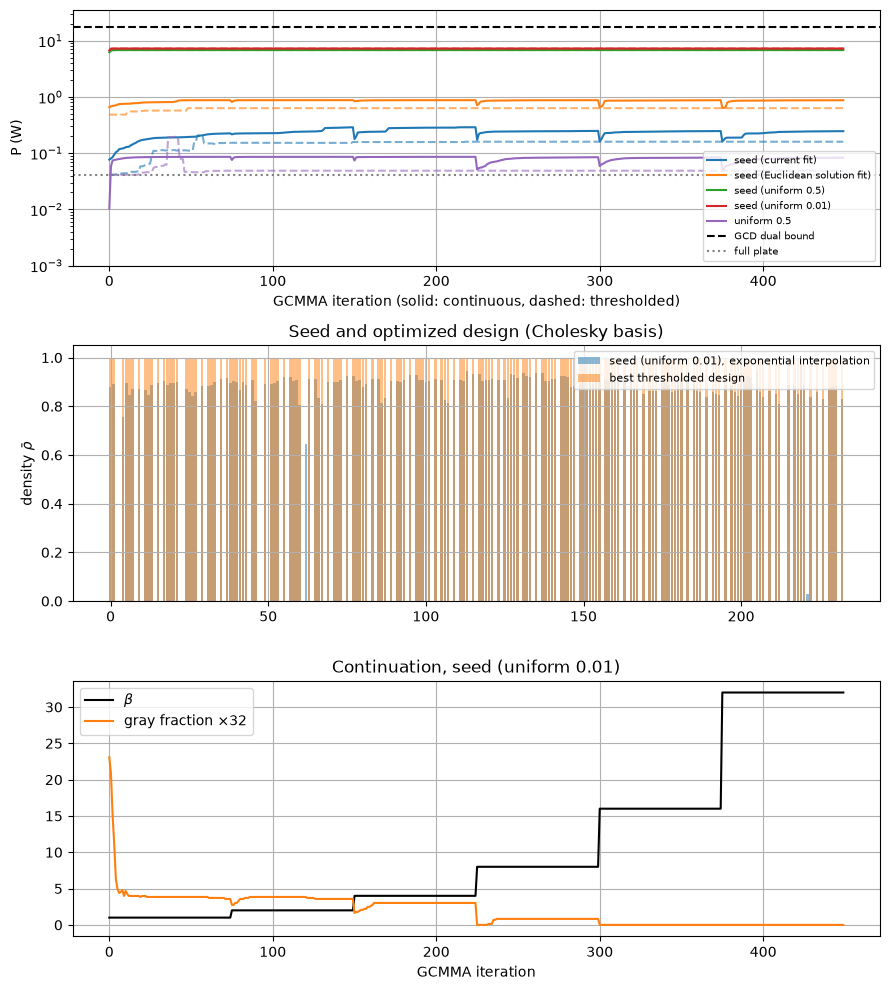

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(9, 10))
for name, (rhoOpt, rhoBin, hist) in topo.items():
    l, = axes[0].semilogy(hist[:, 1], label=name)
    axes[0].semilogy(np.maximum(hist[:, 2], 1e-12), '--', c=l.get_color(), alpha=0.6)
axes[0].axhline(gQCQP.current_dual, ls='--', c='k', label='GCD dual bound')
axes[0].axhline(Pfull, ls=':', c='gray', label='full plate')
axes[0].set_ylim(1e-3, 2*gQCQP.current_dual)
axes[0].set_xlabel('GCMMA iteration (solid: continuous, dashed: thresholded)'); axes[0].set_ylabel('P (W)')
axes[0].legend(fontsize=7); axes[0].grid(True)

axes[1].bar(np.arange(Ndes), starts[bestTO], alpha=0.5, label=f'{bestTO}, exponential interpolation')
axes[1].bar(np.arange(Ndes), topo[bestTO][1], alpha=0.5, label='best thresholded design')
axes[1].set_ylabel(r'density $\bar\rho$'); axes[1].set_title('Seed and optimized design (Cholesky basis)')
axes[1].legend(fontsize=8); axes[1].grid(True)

hb = topo[bestTO][2]
axes[2].plot(hb[:, 0], 'k-', label=r'$\beta$')
axes[2].plot(hb[:, 4]*32, 'C1-', label=r'gray fraction $\times 32$')
axes[2].set_xlabel('GCMMA iteration'); axes[2].set_title(f'Continuation, {bestTO}'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()

## Binary optimization by TSGA

The binary design is optimized directly by TSGA, the topology sensitivity + genetic algorithm of AToM
(`TS_BF.TSsolver.topoOptGreedy` and `geneticsAndTopoOptGreedy`; M. Capek, L. Jelinek, M. Gustafsson, *IEEE TAP* 67, 3889 (2019)),
ported to Python in the same Cholesky basis. Each basis function is either copper or removed ($I_i = 0$), so the design is the active set
$\mathcal A$ with $Z_{\mathcal A\mathcal A} I_\mathcal A = V_\mathcal A$, $Z = Z_0 + Z_s$, the exact physics of `realizedObj` for binary $\rho$.

* **Topology sensitivity (greedy).** With $Y = Z_{\mathcal A\mathcal A}^{-1}$, the exact current after removing basis function $k$ is
  $I - Y_{:k} I_k / Y_{kk}$ (`topoRemove`), and after adding $b$ it is $[I - X\, i_b;\ i_b]$, $X = Y Z_{\mathcal A b}$,
  $i_b = (V_b - Z_{b\mathcal A} I)/(Z_{bb} - Z_{b\mathcal A} X)$ (`topoAdd`). All $N$ candidates are evaluated at once, the one with the largest
  increase of $P$ is applied (rank-1 update of $Y$), until no flip increases $P$ (or the relative increase is below `relTol`).
* **GA.** Elitist single-objective GA (tournament selection, uniform crossover with probability 0.2, one-bit mutation, as `SOGA` with
  `PC = 0.2`, `nMP = 1`); every offspring is refined by the greedy topology sensitivity (Lamarckian), with `relTol` from $10^{-2}$ to
  $10^{-3.5}$ over the generations.

Seeds: the binarized fitted seeds (thresholded at all levels of their exponential-interpolation density, i.e. at impedance levels), the thresholded
density-based designs, and the full plate. TSGA is run with these seeds in the initial population and, as the reference, from a random population.

In [14]:
# TSGA: greedy topology sensitivity (exact rank-1 updates) + single-objective GA, after AToM TS_BF
# (topoOptGreedy, topoRemove, topoAdd, geneticsAndTopoOptGreedy); a basis function is either copper or removed
Zt = Z0 + Zs*np.eye(Ndes)   # system matrix of the full structure (Cholesky basis)

def tsPower(A, I):
    return 0.5*np.real(np.vdot(I, R0[np.ix_(A, A)] @ I))

def tsGreedy(gene, relTol=0.0, maxIt=10**6):
    # greedy topology sensitivity: flip the basis function with the largest exact increase of P until none increases it
    A = np.flatnonzero(gene)
    if A.size == 0:   # empty structure: start from the best single basis function
        A = np.array([np.argmax([tsPower([j], Vinc[[j]]/Zt[j, j]) for j in range(Ndes)])])
    Y = np.linalg.inv(Zt[np.ix_(A, A)])
    I = Y @ Vinc[A]
    Ps, nIt = [tsPower(A, I)], 0
    while nIt < maxIt:
        nIt += 1
        RAA = R0[np.ix_(A, A)]
        # removal of each active basis function (topoRemove): column k is the current without basis function k
        IBr = I[:, None] - Y*(I/np.diag(Y))[None, :]
        Prem = 0.5*np.real(np.sum(np.conj(IBr)*(RAA @ IBr), axis=0)) if A.size > 1 else np.array([-np.inf])
        # addition of each inactive basis function (topoAdd, Schur complement)
        B = np.setdiff1d(np.arange(Ndes), A)
        if B.size:
            ZAB, ZBA = Zt[np.ix_(A, B)], Zt[np.ix_(B, A)]
            X = Y @ ZAB
            s = np.diag(Zt)[B] - np.sum(ZBA.T*X, axis=0)
            ia = (Vinc[B] - ZBA @ I)/s
            Ia = I[:, None] - X*ia[None, :]
            Padd = 0.5*(np.real(np.sum(np.conj(Ia)*(RAA @ Ia), axis=0))
                        + 2*np.real(ia*np.sum(np.conj(Ia)*R0[np.ix_(A, B)], axis=0))
                        + np.real(np.diag(R0)[B])*np.abs(ia)**2)
        else:
            Padd = np.array([-np.inf])
        kr, ka = np.argmax(Prem), np.argmax(Padd)
        Pnew = max(Prem[kr], Padd[ka])
        if Pnew <= Ps[-1] or (Pnew - Ps[-1]) <= relTol*abs(Ps[-1]):
            break
        if Prem[kr] >= Padd[ka]:   # remove A[kr]: Y <- Y - Y[:,k] Y[k,:]/Y[k,k]
            I = np.delete(IBr[:, kr], kr)
            Y = np.delete(np.delete(Y - np.outer(Y[:, kr], Y[kr, :])/Y[kr, kr], kr, 0), kr, 1)
            A = np.delete(A, kr)
        else:                      # add B[ka]: bordered inverse
            b, x, w = B[ka], X[:, ka], ZBA[ka] @ Y
            Y = np.block([[Y + np.outer(x, w)/s[ka], -x[:, None]/s[ka]], [-w[None, :]/s[ka], np.array([[1/s[ka]]])]])
            I = np.append(Ia[:, ka], ia[ka])
            A = np.append(A, b)
            order = np.argsort(A)
            A, I, Y = A[order], I[order], Y[np.ix_(order, order)]
        Ps.append(Pnew)
    gene = np.zeros(Ndes, dtype=bool)
    gene[A] = True
    return gene, np.array(Ps)

def tsga(initGenes, nAgents=16, nGen=15, pCross=0.2, relTols=None, rng=None, verbose=True):
    # elitist single-objective GA (tournament selection, uniform crossover, one-bit mutation), every offspring refined by
    # tsGreedy (Lamarckian); the first generation is the initial genes (filled up with random ones), evaluated without TS
    rng = np.random.default_rng(0) if rng is None else rng
    relTols = np.logspace(-2, -3.5, nGen) if relTols is None else relTols
    pop = [np.asarray(g, dtype=bool) for g in initGenes][:nAgents]
    pop += [rng.random(Ndes) < 0.5 for _ in range(nAgents - len(pop))]
    fit = np.array([realizedObj(g.astype(float)) for g in pop])
    hist = [fit.max()]
    for gen in range(nGen):
        kids = []
        for _ in range(nAgents):
            p1, p2 = [max(rng.choice(nAgents, 2, replace=False), key=lambda i: fit[i]) for _ in range(2)]
            child = np.where(rng.random(Ndes) < 0.5, pop[p1], pop[p2]) if rng.random() < pCross else pop[p1].copy()
            child[rng.integers(Ndes)] ^= True
            kids.append(tsGreedy(child, relTol=relTols[gen])[0])
        kfit = np.array([realizedObj(g.astype(float)) for g in kids])
        allG, allF = pop + kids, np.concatenate([fit, kfit])
        keep = np.argsort(-allF)[:nAgents]
        pop, fit = [allG[i] for i in keep], allF[keep]
        hist.append(fit[0])
        if verbose:
            print(f"generation {gen + 1:3d}: best {fit[0]:.6e} W, median {np.median(fit):.6e} W, {int(pop[0].sum())}/{Ndes} filled")
    return pop[0], fit[0], np.array(hist)


# check: tracked power of a greedy run and exact power of its design
geneT = np.random.default_rng(1).random(Ndes) < 0.6
geneT2, PsT = tsGreedy(geneT, maxIt=10)
print(f"greedy check: {len(PsT) - 1} flips, tracked P {PsT[-1]:.10e} W, exact {realizedObj(geneT2.astype(float)):.10e} W")

greedy check: 10 flips, tracked P 6.0940300912e+00 W, exact 6.0940300884e+00 W


In [15]:
binSeeds = {(name, t): rho > t for name, rho in seedsExp.items() for t in ths}
tsBin = {key: tsGreedy(g) for key, g in binSeeds.items()}
for name in seedsExp:
    PT = np.array([tsBin[(name, t)][1][-1] for t in ths])
    print(f"TS greedy from binarized {name:32s}: best {PT.max():.6e} W (threshold {ths[np.argmax(PT)]:.2f}), median {np.median(PT):.6e} W")
tsTO = {name: tsGreedy(topo[name][1] > 0.5) for name in topo}
for name, (g, Ps) in tsTO.items():
    print(f"TS greedy from density-based design ({name:32s}): {Ps[0]:.6e} -> {Ps[-1]:.6e} W, {len(Ps) - 1} flips")
tsFull = tsGreedy(np.ones(Ndes, dtype=bool))
print(f"TS greedy from the full plate: {tsFull[1][0]:.6e} -> {tsFull[1][-1]:.6e} W")

t1 = time.time()
bestBin = sorted(binSeeds, key=lambda key: -tsBin[key][1][-1])[:8]   # binarized seeds with the best greedy results
initSeeded = [binSeeds[key] for key in bestBin] + [topo[name][1] > 0.5 for name in seedsExp] + [np.ones(Ndes, dtype=bool)]
geneGA, PGA, histGA = tsga(initSeeded, rng=np.random.default_rng(0), verbose=False)
geneGAr, PGAr, histGAr = tsga([], rng=np.random.default_rng(0), verbose=False)
print(f"TSGA, seeded population: {PGA:.6e} W ({int(geneGA.sum())}/{Ndes} filled); random population: {PGAr:.6e} W; {time.time()-t1:.2f}s")

TS greedy from binarized seed (current fit)              : best 7.742235e+00 W (threshold 0.75), median 6.048023e+00 W
TS greedy from binarized seed (Euclidean solution fit)   : best 1.524338e+01 W (threshold 0.80), median 1.505118e+01 W
TS greedy from binarized seed (uniform 0.5)              : best 8.987760e+00 W (threshold 0.05), median 8.970698e+00 W
TS greedy from binarized seed (uniform 0.01)             : best 8.984964e+00 W (threshold 0.85), median 8.781957e+00 W
TS greedy from density-based design (seed (current fit)              ): 2.067719e-01 -> 7.010857e+00 W, 54 flips
TS greedy from density-based design (seed (Euclidean solution fit)   ): 6.315643e-01 -> 1.512556e+01 W, 13 flips
TS greedy from density-based design (seed (uniform 0.5)              ): 6.814934e+00 -> 8.919318e+00 W, 18 flips
TS greedy from density-based design (seed (uniform 0.01)             ): 7.258159e+00 -> 8.913138e+00 W, 11 flips
TS greedy from density-based design (uniform 0.5                     ): 

TS greedy from the full plate: 4.114174e-02 -> 6.048023e+00 W


TSGA, seeded population: 1.538717e+01 W (167/233 filled); random population: 9.299358e+00 W; 2.33s


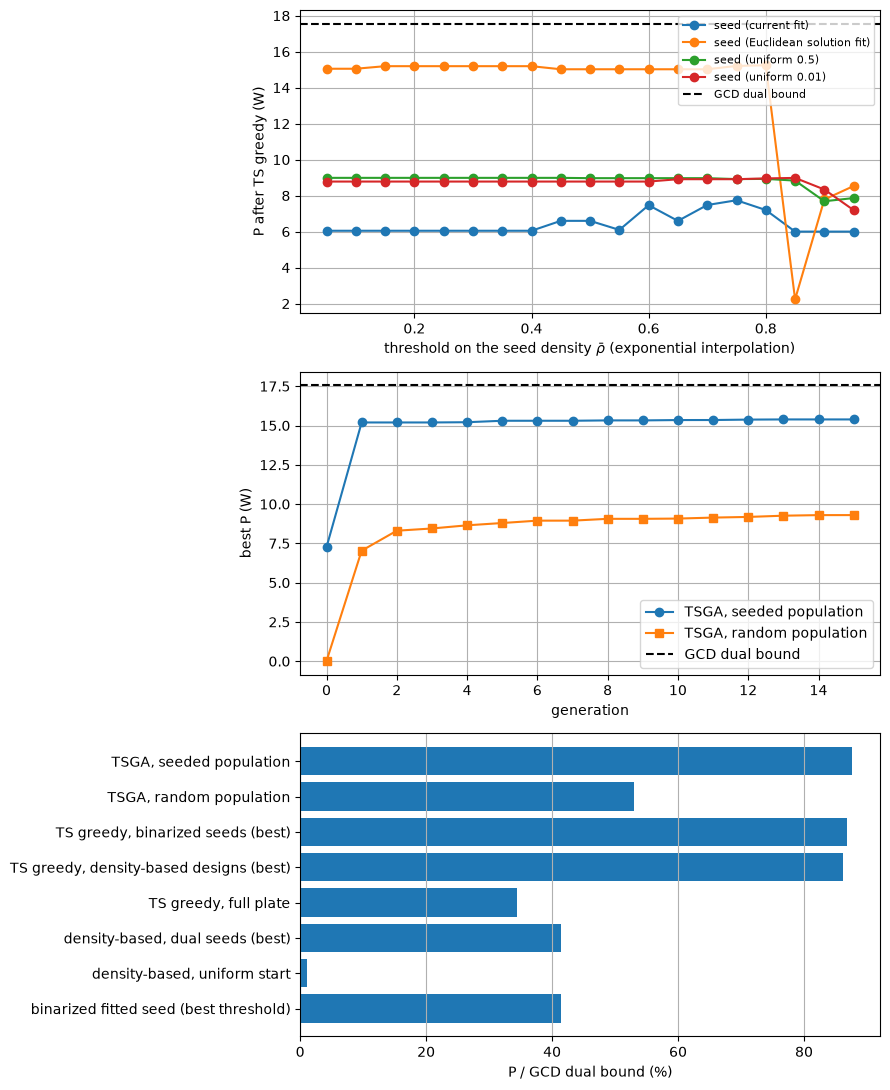

GCD dual bound 1.754994e+01 W (100 iterations), global bound 1.847944e+01 W, full plate 4.114174e-02 W
binarized fitted seed (best threshold)     7.258159e+00 W   41.36% of the bound
density-based, uniform start               1.957312e-01 W    1.12% of the bound
density-based, dual seeds (best)           7.258159e+00 W   41.36% of the bound
TS greedy, full plate                      6.048023e+00 W   34.46% of the bound
TS greedy, density-based designs (best)    1.512556e+01 W   86.19% of the bound
TS greedy, binarized seeds (best)          1.524338e+01 W   86.86% of the bound
TSGA, random population                    9.299358e+00 W   52.99% of the bound
TSGA, seeded population                    1.538717e+01 W   87.68% of the bound


In [16]:
PbinSeed = max(realizedObj(g.astype(float)) for g in binSeeds.values())
summary = [("binarized fitted seed (best threshold)", PbinSeed),
           ("density-based, uniform start", realizedObj(topo["uniform 0.5"][1])),
           ("density-based, dual seeds (best)", realizedObj(topo[bestTO][1])),
           ("TS greedy, full plate", tsFull[1][-1]),
           ("TS greedy, density-based designs (best)", max(Ps[-1] for _, Ps in tsTO.values())),
           ("TS greedy, binarized seeds (best)", max(Ps[-1] for _, Ps in tsBin.values())),
           ("TSGA, random population", PGAr),
           ("TSGA, seeded population", PGA)]

fig, axes = plt.subplots(3, 1, figsize=(9, 11))
for name in seedsExp:
    axes[0].plot(ths, [tsBin[(name, t)][1][-1] for t in ths], 'o-', label=name)
axes[0].axhline(gQCQP.current_dual, ls='--', c='k', label='GCD dual bound')
axes[0].set_xlabel(r'threshold on the seed density $\bar\rho$ (exponential interpolation)')
axes[0].set_ylabel('P after TS greedy (W)'); axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].plot(histGA, 'o-', label='TSGA, seeded population')
axes[1].plot(histGAr, 's-', label='TSGA, random population')
axes[1].axhline(gQCQP.current_dual, ls='--', c='k', label='GCD dual bound')
axes[1].set_xlabel('generation'); axes[1].set_ylabel('best P (W)'); axes[1].legend(); axes[1].grid(True)

axes[2].barh([n for n, _ in summary], [100*P/gQCQP.current_dual for _, P in summary])
axes[2].set_xlabel('P / GCD dual bound (%)'); axes[2].grid(True, axis='x')
plt.tight_layout(); plt.show()

print(f"GCD dual bound {gQCQP.current_dual:.6e} W ({Ngcd} iterations), global bound {QCQP.current_dual:.6e} W, full plate {Pfull:.6e} W")
for name, P in summary:
    print(f"{name:42s} {P:.6e} W  {100*P/gQCQP.current_dual:6.2f}% of the bound")